In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report , confusion_matrix, accuracy_score


In [4]:
# load dataset 
data = load_breast_cancer()

# convert to Dataframe
df= pd.DataFrame(data.data, columns=data.feature_names)
df['target']= data.target

In [5]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [6]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
df.shape


(569, 31)

In [8]:
df.isnull()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
x= df.drop('target', axis =1)
y= df['target']


In [11]:

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.1, random_state =42)
x_train, x_test, y_train , y_test = train_test_split(x,y, test_size= 0.2, random_state= 42)


In [12]:
x_train.shape


(455, 30)

In [13]:
x_train.size

13650

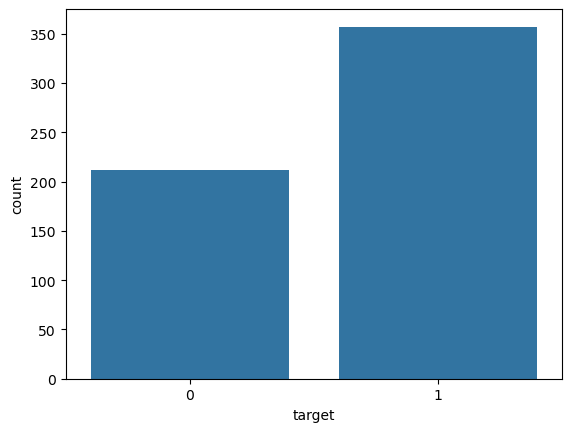

In [14]:
sns.countplot(x=y)
plt.show()

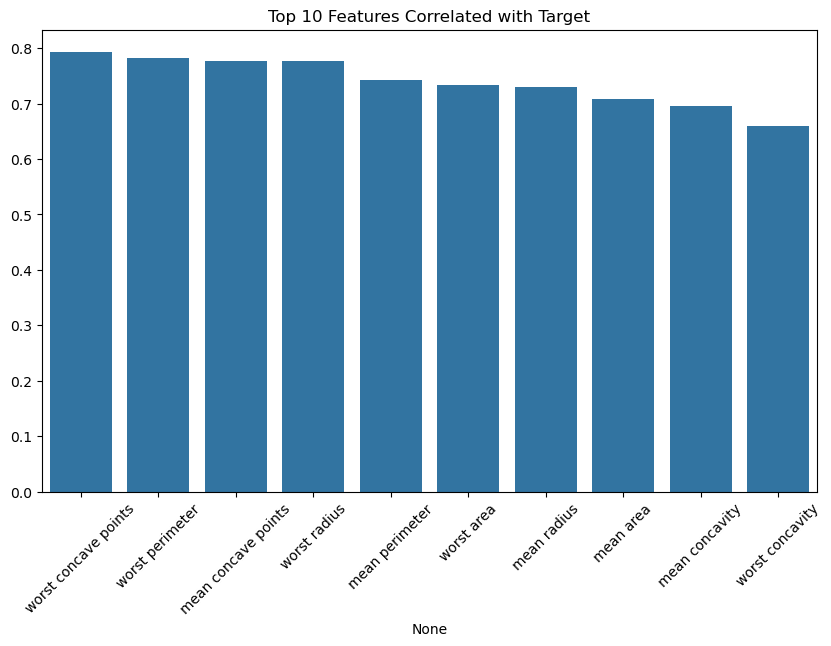

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x=df.corr()['target'][:-1].abs().sort_values(ascending=False)[:10].index,
            y=df.corr()['target'][:-1].abs().sort_values(ascending=False)[:10].values)
plt.title("Top 10 Features Correlated with Target")
plt.xticks(rotation=45)
plt.show()

In [42]:
# Build Decision Tree Classifier
model = DecisionTreeClassifier(
    criterion="gini",   # or "entropy"
    max_depth=500,     # no limit (risk of overfitting)
    random_state=42
)

# Train the model
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=500, random_state=42)

In [43]:
# prediction 
y_pred = model.predict(x_test)

In [55]:
print("Accuracy:", accuracy_score(y_train, model.predict(x_train)))     # real ma mero 100% ayo but test garda 94% aayo
                                                                    # yesto case ma pruning use garney (list_depth )

Accuracy: 1.0


In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9473684210526315


In [45]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=data.target_names))



Classification Report:
               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



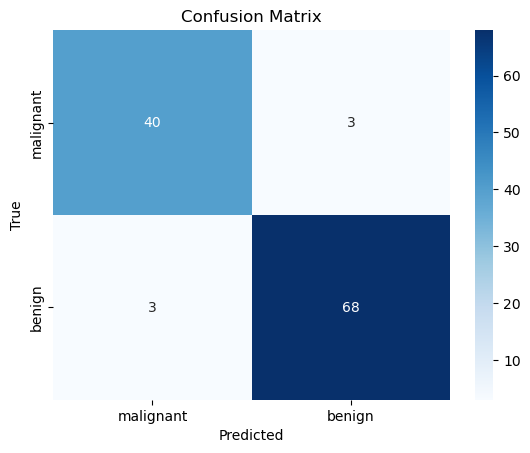

In [46]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

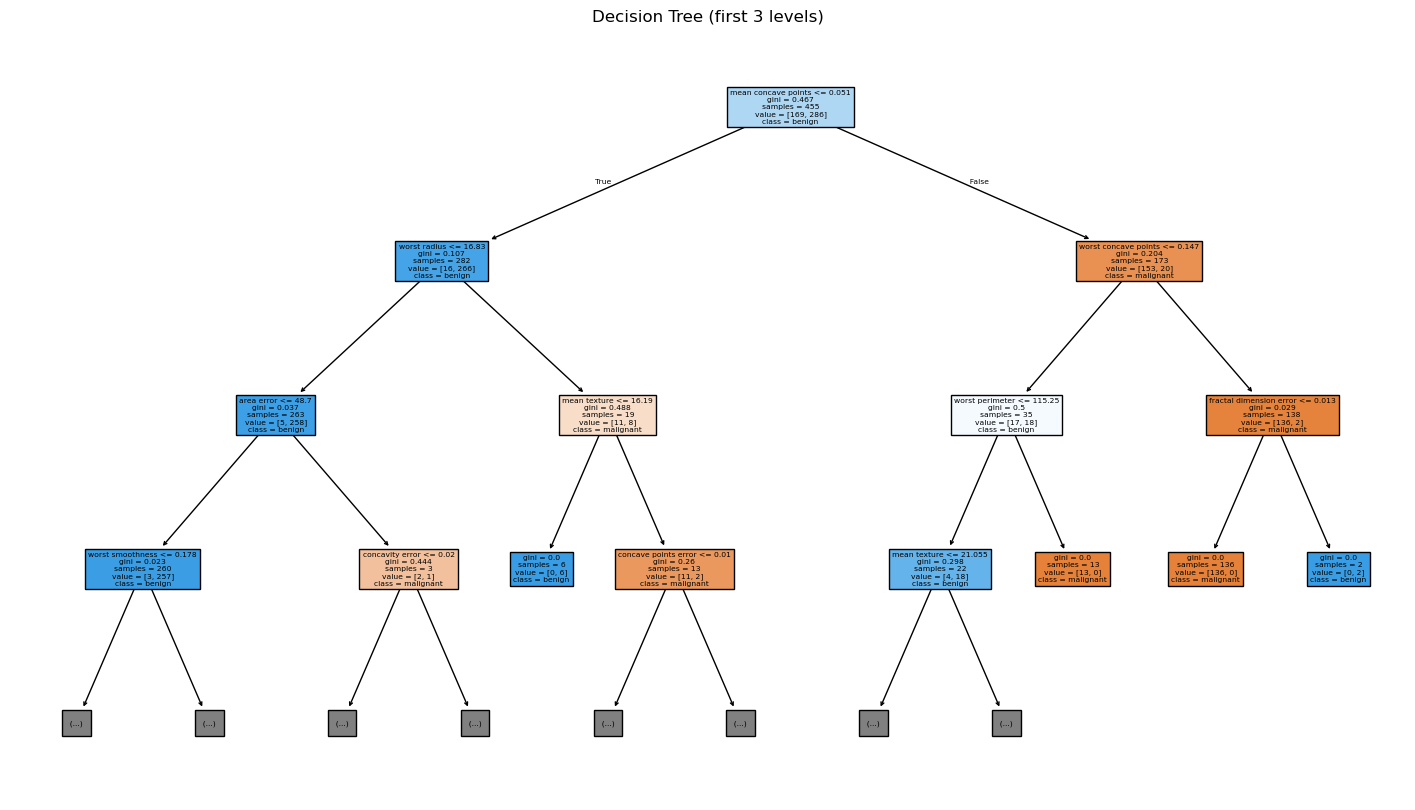

In [23]:
plt.figure(figsize=(18,10))
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True, max_depth=3)
plt.title("Decision Tree (first 3 levels)")
plt.show()

In [47]:
x_test[:1]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
204,12.47,18.6,81.09,481.9,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,...,14.97,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875


In [52]:
x_test.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,...,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,14.165833,19.707193,92.315439,656.930702,0.098820,0.107221,0.088405,0.051471,0.181414,0.062961,...,16.405237,26.242105,107.892193,894.935965,0.135707,0.260345,0.262585,0.116299,0.288373,0.084257
std,3.491876,4.432655,24.310746,341.074645,0.014415,0.054297,0.081070,0.041715,0.027240,0.006457,...,4.939138,6.456743,34.640172,578.333677,0.021581,0.166857,0.206139,0.067596,0.056683,0.018967
min,6.981000,10.940000,43.790000,143.500000,0.068280,0.035580,0.000000,0.000000,0.106000,0.052660,...,7.930000,12.490000,50.410000,185.200000,0.087990,0.054940,0.000000,0.000000,0.156600,0.059050
25%,11.687500,16.217500,75.225000,418.625000,0.088968,0.069655,0.030053,0.019842,0.163175,0.058428,...,12.850000,21.260000,84.012500,505.750000,0.121975,0.150850,0.102495,0.069250,0.251600,0.072400
50%,13.465000,19.535000,87.380000,548.700000,0.099085,0.097565,0.062960,0.033950,0.179400,0.061580,...,14.945000,25.790000,97.155000,681.200000,0.135850,0.215550,0.228450,0.101500,0.280850,0.079750
75%,16.057500,22.675000,105.300000,806.800000,0.106950,0.127800,0.119300,0.072967,0.193925,0.066405,...,19.695000,30.042500,129.175000,1211.000000,0.145175,0.316275,0.369850,0.166950,0.318925,0.092120
max,25.220000,31.120000,171.500000,1878.000000,0.137100,0.345400,0.375400,0.184500,0.290600,0.082430,...,32.490000,47.160000,214.000000,3432.000000,0.222600,1.058000,1.105000,0.286700,0.544000,0.207500


In [53]:
x_test.info

<bound method DataFrame.info of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
204        12.47         18.60           81.09      481.9          0.09965   
70         18.94         21.31          123.60     1130.0          0.09009   
131        15.46         19.48          101.70      748.9          0.10920   
431        12.40         17.68           81.47      467.8          0.10540   
540        11.54         14.44           74.65      402.9          0.09984   
..           ...           ...             ...        ...              ...   
486        14.64         16.85           94.21      666.0          0.08641   
75         16.07         19.65          104.10      817.7          0.09168   
249        11.52         14.93           73.87      406.3          0.10130   
238        14.22         27.85           92.55      623.9          0.08223   
265        20.73         31.12          135.70     1419.0          0.09469   

     mean compactness  mean con